<a href="https://colab.research.google.com/github/LombogRonnXherxes/CPE018-Emerging-Technologies-1/blob/main/Hands_on_Activity_8_1_ORB_Feature_Detection_and_Feature_Matching_Lombog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<hr> | <hr>
<u>8 | ORB Feature Detection and Feature Matching
**Name** | Lombog, Ronn Xherxes D.
**Section** | CPE31S2
**Date Performed**: |March 24, 2026
**Date Submitted**: |March 24, 2026
**Instructor**: | Engr. Rizette Sayo

<hr>

## 1. Objectives

This activity aims to enable students to perform feature detection and feature matching using Oriented FAST and Rotated BRIEF (ORB) algorithm with OpenCV.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.
* Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.

## 3. Procedures and Outputs

**BEFORE YOU PROCEED WITH THIS SECTION: PLEASE MAKE SURE YOU HAVE READ THE CONTENTS OF THE MODULE REGARDING BRIEF AND FAST**

The team that created ORB (Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski) chose to build it on FAST and BRIEF because these two algorithms are fast and efficient.

In their paper, the authors of ORB set out to achieve the following:

* Add a fast and accurate way to determine the orientation of FAST keypoints.
* Find a way to efficiently compute BRIEF features that are also rotation-invariant.
Analyze the variance and correlation of oriented BRIEF features.
* Develop a learning method to decorrelate BRIEF features under rotational invariance, which would improve performance in nearest-neighbor applications.
* In other words, the ORB team wanted to make feature detection and matching faster and more accurate, especially in situations where the training image and query image have different rotations.

The main points of the text are clear, even if you don't understand all of the technical jargon. ORB is a fast and efficient algorithm for feature detection and matching, and it is especially good at matching features that have different rotations.

I bet you are eager to start coding with ORB, so let's move on to some code examples.

Parts of this activity contribute towards the attainment of `ILO1: Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.`

In [1]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

image1 = cv2.imread('/content/PS4LOGO.jpg', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('/content/PS4BOX.png', cv2.IMREAD_GRAYSCALE)

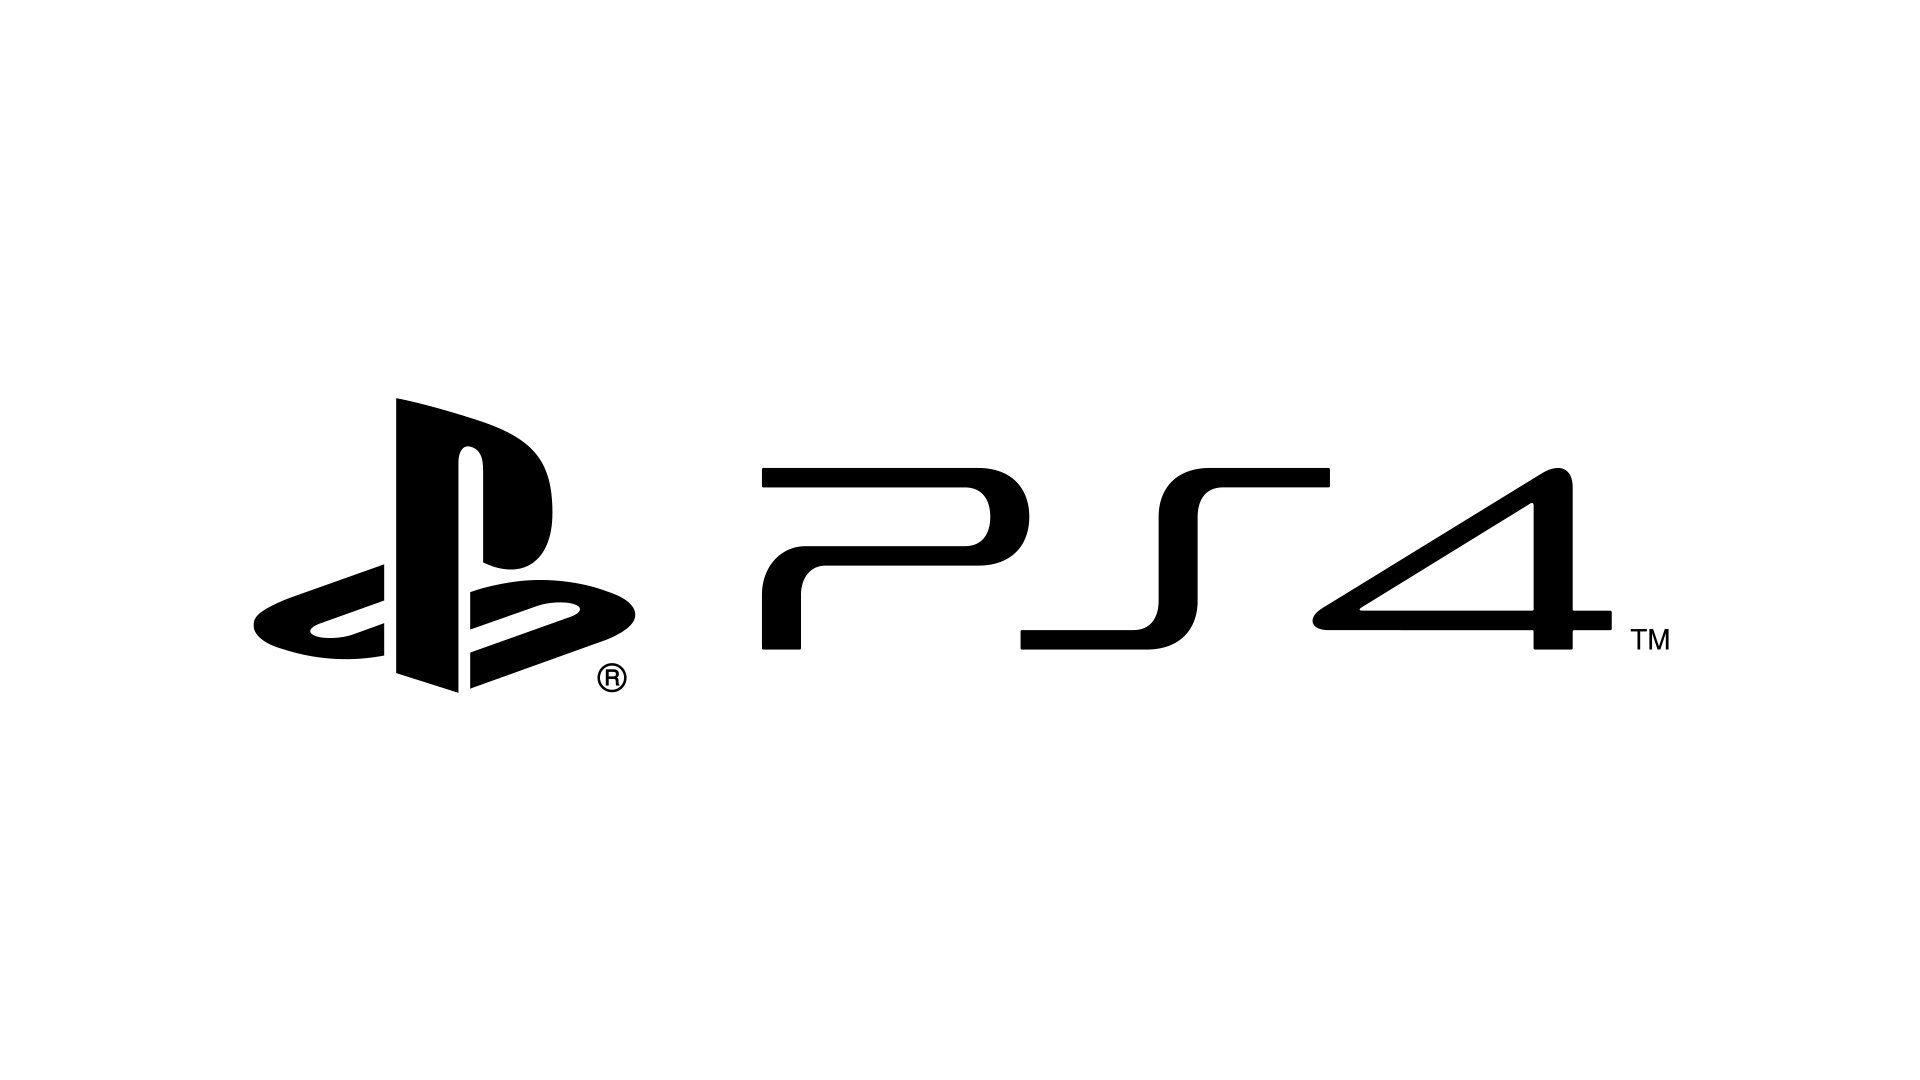

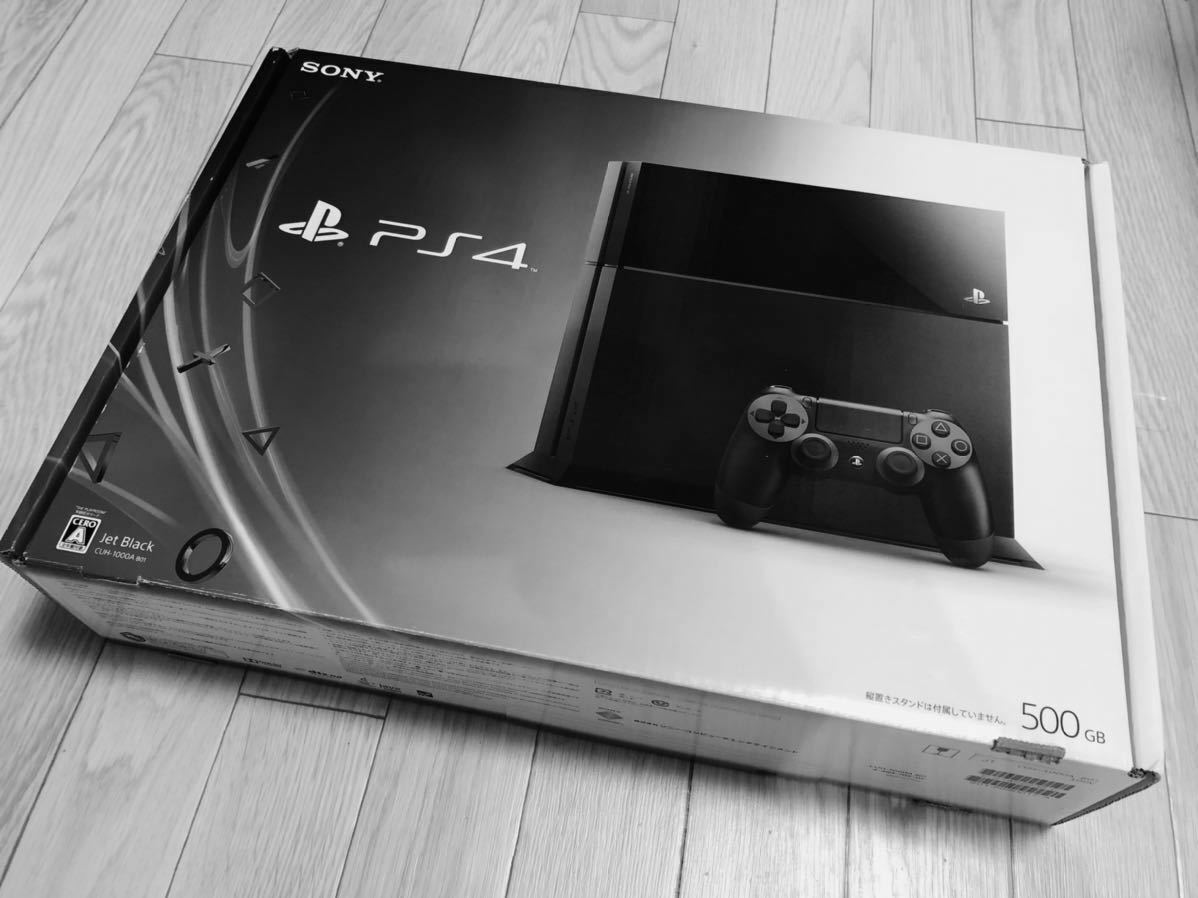

In [2]:
# Preview the 2 images
cv2_imshow(image1)
cv2_imshow(image2)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Create the ORB feature and detector descriptor
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(image1,None) # Reference image
kp2, des2 = orb.detectAndCompute(image2,None)

**Analysis: Explain the purpose of detector and descriptor and why they're used here.**

The ORB algorithm uses a detector to identify distinct keypoints in the images and a descriptor to summarize the visual information surrounding those points, allowing the code to effectively compare and match unique features between the reference and target images.

In [5]:
"""
The BFMatcher is a simple but effective algorithm for feature matching.
It works by comparing each feature in one image to every feature in the other
image and returning the pair of features with the smallest distance.
"""

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

"""
The match() method takes two arguments:
  - the descriptors of the features in the first image
  - the descriptors of the features in the second image.

It returns a list of matches, where each match is a pair of feature indices,
one from each image.
"""

matches = bf.match(des1,des2)


In [6]:

"""
Next, we sort the matches in order of their distance.
This ensures that the best matches are returned first.
"""
sorted_matches = sorted(matches, key = lambda x:x.distance)

"""
Then, we draw the top 40 matches between the two images.
The drawMatches() method takes two arguments: the two images, and a list of matches.
It draws lines between the corresponding keypoints in the two images.
"""

image3 = cv2.drawMatches(image1,kp1,image2,kp2, sorted_matches[:40],image2,flags=2)

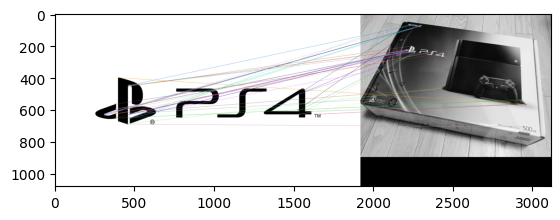

(<matplotlib.image.AxesImage at 0x7a0f1032cf80>, None)

In [9]:
from matplotlib import pyplot as plt

plt.imshow(image3),plt.show()

**Question**
- Provide an analysis on the way the ORB algorithm works here, are the results correct? What can/should be improved?

The ORB algorithm effectively identifies key features on the logos and console packaging, but the results contain several "false positives" or incorrect matches where lines cross haphazardly rather than connecting corresponding points. To improve accuracy, you should implement a RANSAC-based homography to filter out geometrically inconsistent matches or use a ratio test to ensure each match is significantly better than the next best alternative.

## 4. Supplementary Activity

**ILO2: Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.**

Perform the following tasks:
1. Find 2 images of brand logos on the internet.
2. Find 5 product images containing one logo each.
3. Test the ORB algorithm to detect and match the features on the images. Document the testing.
4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?
5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?

In [19]:
import cv2
import matplotlib.pyplot as plt

# Load 2 Reference Logos
logos = [
    cv2.imread('/content/PS4LOGO.jpg', 0),
    cv2.imread('/content/nike-logo.png', 0)
]

# Load 5 Product Images
products = [
    cv2.imread('/content/PS4BOX.png', 0),
    cv2.imread('/content/PS4BOX(2).png', 0),
    cv2.imread('/content/ps4controller.jpg', 0),
    cv2.imread('/content/nike_shoes.png', 0),
    cv2.imread('/content/nike-shoes(2).png', 0)
]

In [20]:
# Initialize ORB with 1000 features for better detail on complex boxes
orb = cv2.ORB_create(nfeatures=1000)

# Initialize the Brute-Force Matcher using Hamming distance
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

In [21]:
# Detect and compute for logos
kp_logos = [orb.detectAndCompute(l, None) for l in logos]

# Detect and compute for all 5 products
kp_prods = [orb.detectAndCompute(p, None) for p in products]

In [22]:
all_results = []

for i in range(5):
    # Logic: Use Logo 0 (PS4) for first 3 prods, Logo 1 (Nike) for last 2
    logo_idx = 0 if i < 3 else 1

    # Get descriptors
    des_logo = kp_logos[logo_idx][1]
    des_prod = kp_prods[i][1]

    # Perform matching and sort by distance
    matches = bf.match(des_logo, des_prod)
    matches = sorted(matches, key=lambda x: x.distance)
    all_results.append(matches)

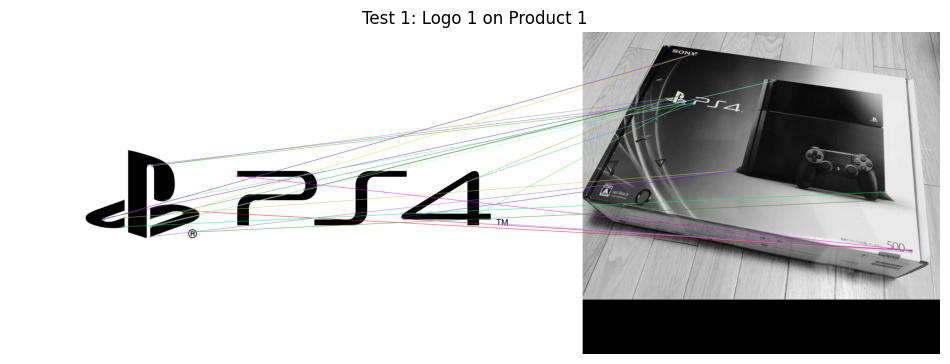

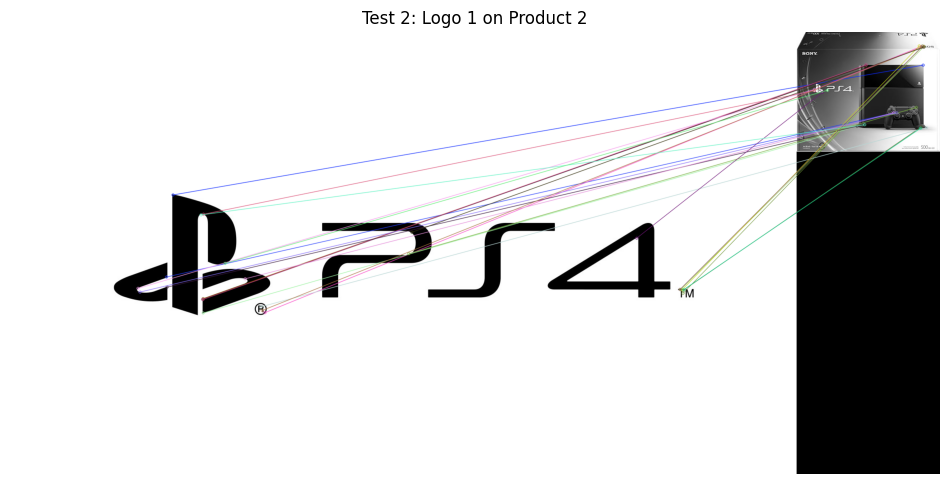

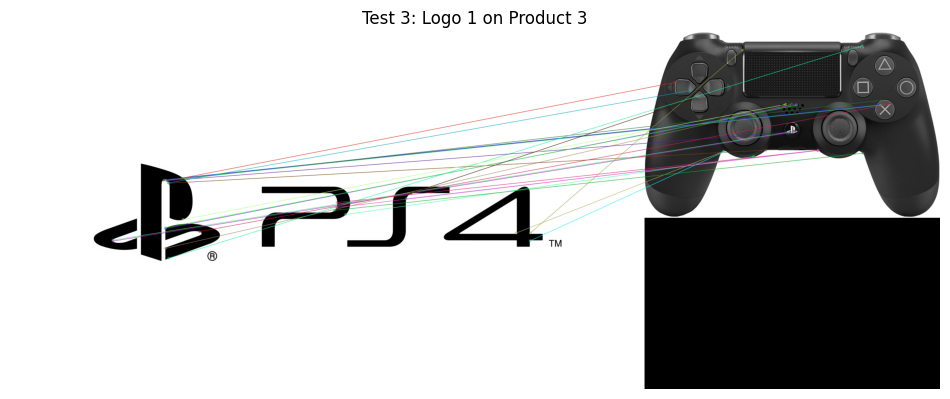

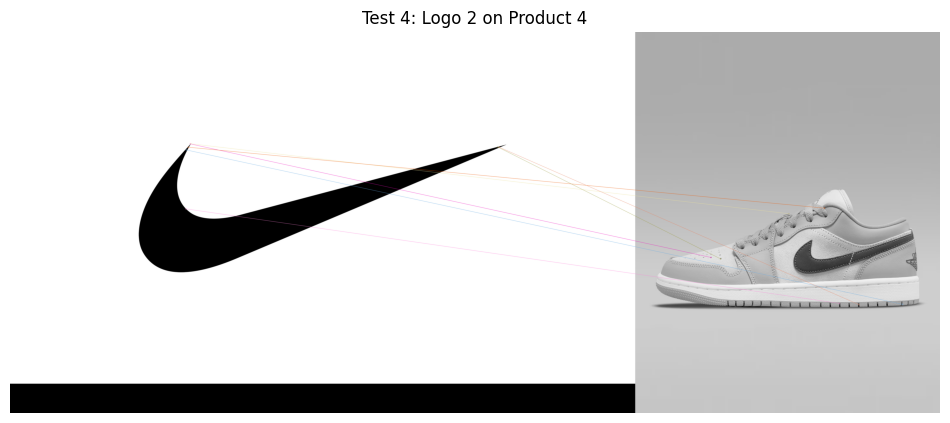

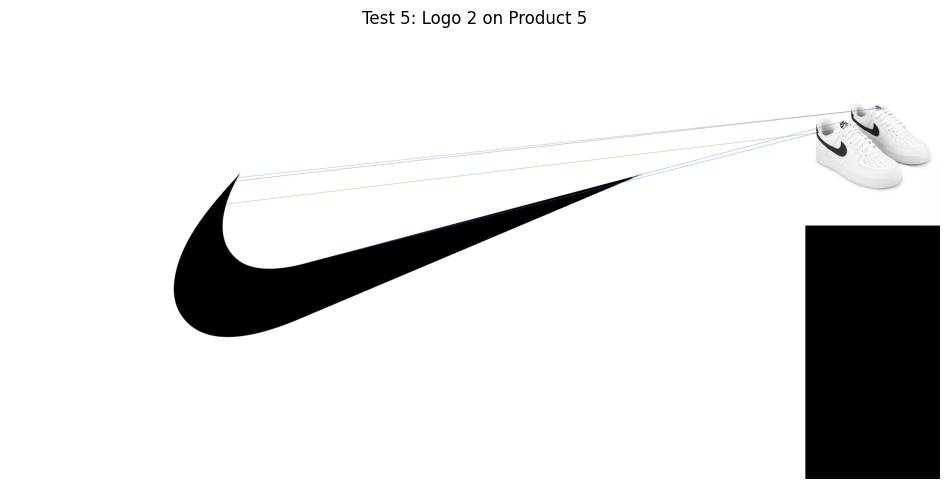

In [23]:
for i in range(5):
    logo_idx = 0 if i < 3 else 1

    # Draw the top 25 matches for a clean visual
    out_img = cv2.drawMatches(logos[logo_idx], kp_logos[logo_idx][0],
                              products[i], kp_prods[i][0],
                              all_results[i][:25], None, flags=2)

    plt.figure(figsize=(12, 6))
    plt.title(f"Test {i+1}: Logo {logo_idx+1} on Product {i+1}")
    plt.imshow(out_img)
    plt.axis('off')
    plt.show()

## 5. Summary, Conclusions and Lessons Learned

The implementation of the ORB algorithm across two distinct brand logos and five product images demonstrates that feature matching is highly effective for identifying high-contrast, geometric shapes like the PS4 and Nike branding. While the algorithm successfully located the logos in various environments, the presence of "false positives" in complex backgrounds highlighted the need for more advanced filtering techniques to ensure spatial consistency. A major conclusion drawn is that ORB provides a superior balance of speed and rotation invariance compared to older methods, making it ideal for real-time consumer product recognition. The testing process revealed that reliability drops significantly when the target logo is partially obscured or when the background contains repetitive patterns that mimic the logo's descriptors. Ultimately, this project teaches that while automated detection is powerful, achieving professional-grade accuracy requires implementing a Ratio Test or RANSAC to mathematically verify that the matches align with the physical structure of the product.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*